# Trabajo Práctico 1: Regresión Lineal

**Asignatura:** Aprendizaje Automático I
**Curso:** 2026 C2
**Integrantes:** Ibarbia, Colombo, Ayala

> *El código debe estar comentado: una línea por celda para su comprensión, y comentarios adicionales que justifiquen las decisiones metodológicas adoptadas.*

## 1. Objetivos

Familiarizarse con la biblioteca scikit-learn y las herramientas que brinda para el pre-procesamiento de datos, la implementación de modelos de regresión lineal con diversos hiperparámetros y la evaluación de métricas.

## 2. Dataset

El dataset **house-prices.csv** contiene información de precios de casas de Boston, con 14 variables (13 de entrada y 1 target). Las variables incluyen tasa de criminalidad, proporción de terrenos residenciales, concentración de óxidos de nitrógeno, número de habitaciones, entre otras.

In [1]:
# Importación de librerías necesarias para análisis, visualización y modelado
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual para los gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [2]:
# Resolver la ubicación del CSV buscando el repositorio y sus carpetas cercanas.
from pathlib import Path

# Se prioriza la copia versionada del repositorio para garantizar reproducibilidad sin depender de internet.
rutas_dataset = [
    Path.cwd() / 'house-prices-tp.csv',
    Path.cwd().parent / 'house-prices-tp.csv',
    Path.cwd().parent.parent / 'house-prices-tp.csv',
]
ruta_dataset = next((ruta for ruta in rutas_dataset if ruta.exists()), None)

# Si se ejecuta fuera del repositorio, se mantiene una URL de respaldo correctamente identificada.
if ruta_dataset is None:
    url = 'https://raw.githubusercontent.com/manuelibarbia/TP_AAu1_Ibarbia_Colombo_Ayala/main/house-prices-tp.csv'
    df = pd.read_csv(url)
    origen_dataset = url
else:
    df = pd.read_csv(ruta_dataset)
    origen_dataset = ruta_dataset.name

# Validar que el archivo corresponde al problema de regresión planteado.
columnas_esperadas = {'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'}
faltantes = columnas_esperadas.difference(df.columns)
if faltantes:
    raise ValueError(f'Faltan columnas esperadas en el dataset: {sorted(faltantes)}')

print('Origen del dataset:', origen_dataset)
print('Dimensiones del dataset:', df.shape)
print('\nPrimeras filas:')
df.head()

Origen del dataset: house-prices-tp.csv
Dimensiones del dataset: (556, 14)

Primeras filas:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


In [3]:
# Resumir tipos de datos, cardinalidad y estadísticas para conocer la estructura inicial.
print('Información del dataset:')
print('-' * 60)
df.info()

# La tabla transpuesta permite revisar rango, dispersión y escala de cada variable individualmente.
resumen_variables = df.describe().T
resumen_variables['rango'] = resumen_variables['max'] - resumen_variables['min']
resumen_variables['tipo'] = df.dtypes.astype(str)
resumen_variables['valores_unicos'] = df.nunique()
print('\nResumen descriptivo por variable:')
display(resumen_variables[['tipo', 'valores_unicos', 'min', 'max', 'rango', 'mean', 'std']].round(3))

Información del dataset:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB

Resumen descriptivo por variable:


,tipo,valores_unicos,min,max,rango,mean,std
CRIM,float64,531,0.006,88.976,88.970,5.846,13.829
ZN,float64,54,0.000,100.000,100.000,13.197,24.903
INDUS,float64,111,0.460,27.740,27.280,11.219,6.942
CHAS,float64,2,0.000,1.000,1.000,0.090,0.287
NOX,float64,107,0.385,0.871,0.486,0.560,0.119
RM,float64,475,3.561,8.780,5.219,6.292,0.782
AGE,float64,382,2.900,100.000,97.100,67.632,28.462
DIS,float64,447,1.130,12.126,10.997,3.944,2.256
RAD,float64,31,1.000,24.000,23.000,9.699,8.684
TAX,float64,98,187.000,711.000,524.000,409.575,167.689


---

## Consigna 3: Análisis descriptivo

Se describen las variables, los faltantes, las relaciones con MEDV y el preprocesamiento. CHAS ya es una variable dummy numérica 0/1, por lo que no requiere codificación adicional.

In [4]:
# Revisar faltantes y definir el tratamiento antes del modelado.
nulos = df.isna().sum()
df_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos / len(df) * 100})
display(df_nulos)

# No se imputan targets: las filas sin MEDV no tienen etiqueta supervisada.
df_modelo = df.dropna(subset=['MEDV']).copy()
print(f"Filas originales: {len(df)} | Filas sin MEDV excluidas: {len(df) - len(df_modelo)}")
print('Features faltantes: se imputarán con la mediana aprendida únicamente en train.')

,Nulos,Porcentaje (%)
CRIM,23,4.136691
ZN,22,3.956835
INDUS,15,2.697842
CHAS,23,4.136691
NOX,24,4.316547
RM,21,3.776978
AGE,24,4.316547
DIS,15,2.697842
RAD,28,5.035971
TAX,18,3.237410


Filas originales: 556 | Filas sin MEDV excluidas: 21
Features faltantes: se imputarán con la mediana aprendida únicamente en train.


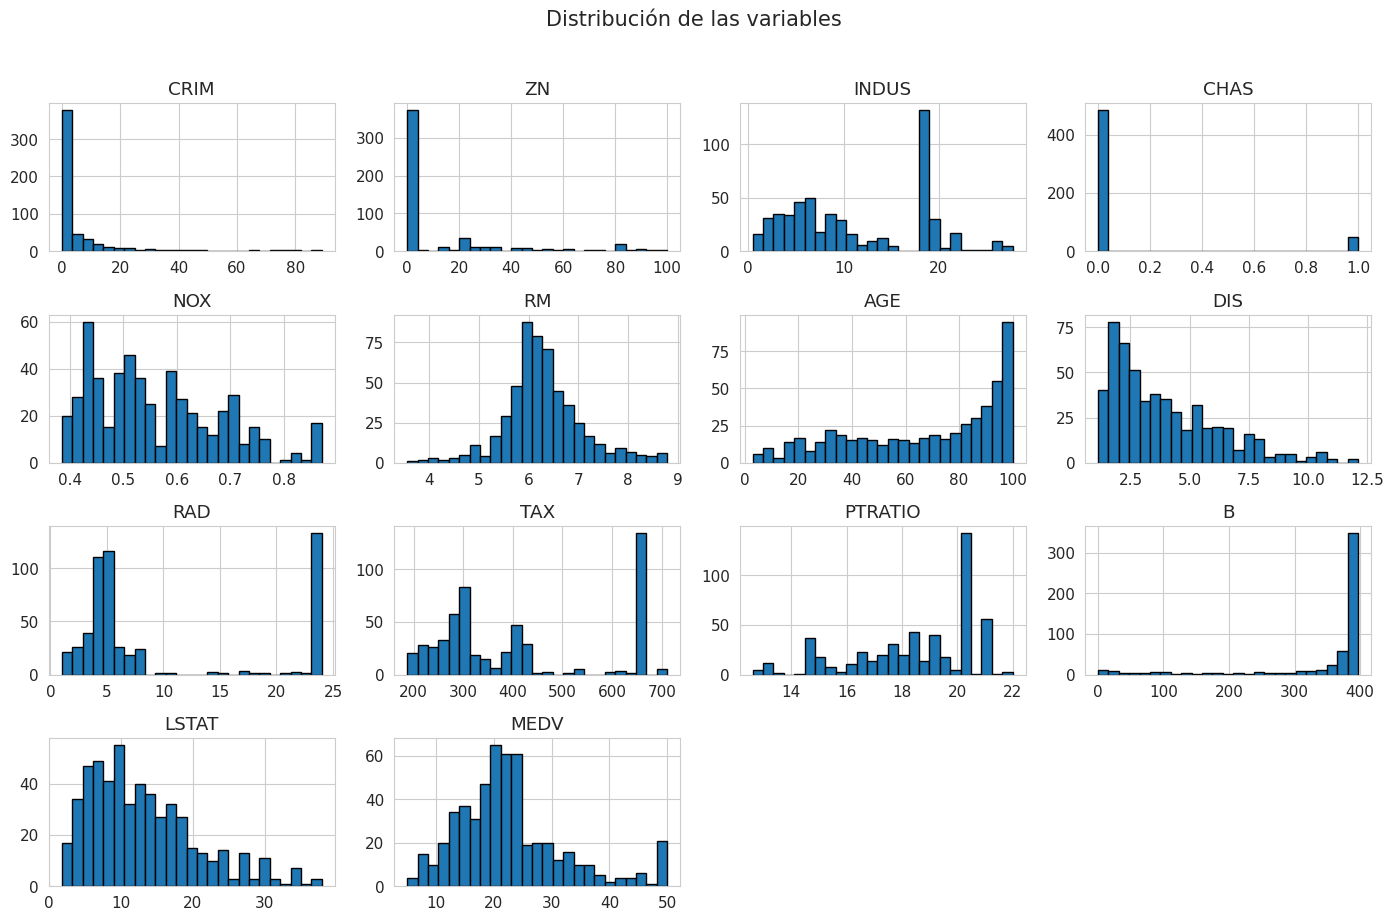

In [5]:
# Visualizar la distribución de todas las variables en una única figura compacta.
axes = df.hist(bins=25, figsize=(14, 9), edgecolor='black')
plt.suptitle('Distribución de las variables', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# Verificar si MEDV está topeada en 50: cuántos valores están en el máximo y cuántos lo superan.
print('Valor máximo de MEDV:', df['MEDV'].max())
print('Filas con MEDV == 50:', (df['MEDV'] == 50).sum())
print('Filas con MEDV > 50:', (df['MEDV'] > 50).sum())
print('\nValores exactos más repetidos de MEDV:')
print(df['MEDV'].value_counts().head(5))

Valor máximo de MEDV: 50.0
Filas con MEDV == 50: 16
Filas con MEDV > 50: 0

Valores exactos más repetidos de MEDV:
MEDV
50.0    16
25.0     8
22.0     7
21.7     7
23.1     7
Name: count, dtype: int64


Las variables CRIM y ZN se concentran cerca de cero con una cola larga a la derecha, mientras que B y AGE se acumulan en valores altos con una cola a la izquierda. RM es la que más se aproxima a una distribución normal. CHAS es binaria, la mayoría de los registros es 0. RAD, TAX, INDUS y PTRATIO presentan picos muy marcados en un único valor. La variable objetivo MEDV tiene forma de campana con cola a la derecha. No hay ningún valor por encima de 50 y 50.0 es el valor exacto más repetido (16 observaciones, el doble que el siguiente), lo que sugiere que los precios están topeados en ese máximo.

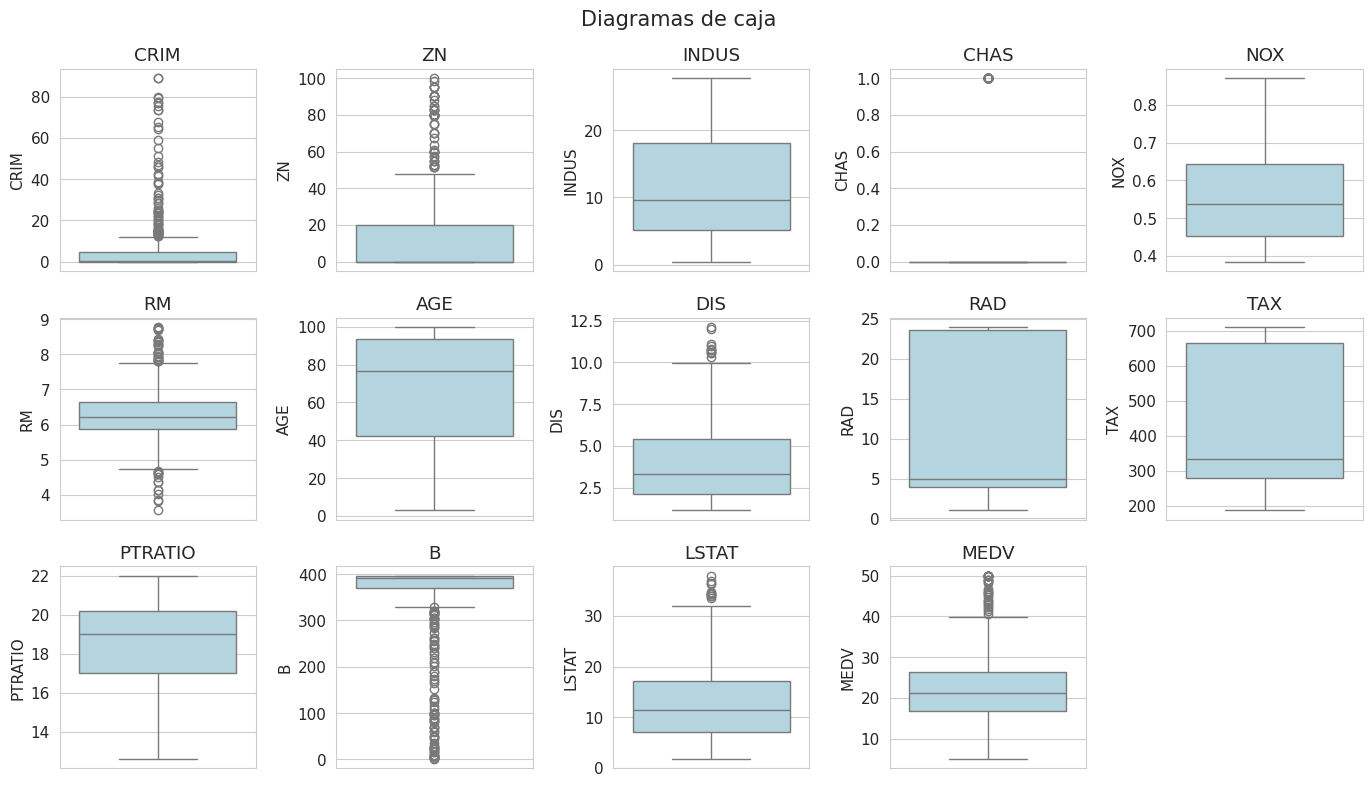

In [7]:
# Identificar dispersión y posibles valores extremos mediante boxplots.
fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for ax, col in zip(axes.flat, df.columns):
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_title(col)
for ax in axes.flat[len(df.columns):]:
    ax.set_visible(False)
plt.suptitle('Diagramas de caja', fontsize=15)
plt.tight_layout()
plt.show()

Los boxplots muestran valores atípicos en CRIM, ZN, B, RM, LSTAT, DIS y MEDV. En CRIM y ZN la caja queda concentrada cerca de cero, con muchos puntos por encima; en B ocurre lo inverso, con la caja cerca de 400 y muchos atípicos hacia abajo. RM es la única con atípicos en ambos extremos. En MEDV los atípicos superiores llegan hasta 50, coherente con el tope observado antes. INDUS, NOX, AGE, RAD, TAX y PTRATIO no presentan atípicos según el criterio de 1.5·IQR. Las cajas de RAD y TAX son muy anchas porque, como se vio en los histogramas, la mayoría de los valores se concentran en un extremo bajo y otro alto, con muy pocos en el medio. En CHAS el boxplot no es informativo por tratarse de una variable binaria. No se eliminaron los valores atípicos, ya que corresponden a zonas plausibles (muy peligrosas, muy caras, etc.) y no hay evidencia de que sean errores; por eso se imputan los faltantes con la mediana, que es robusta a ellos.

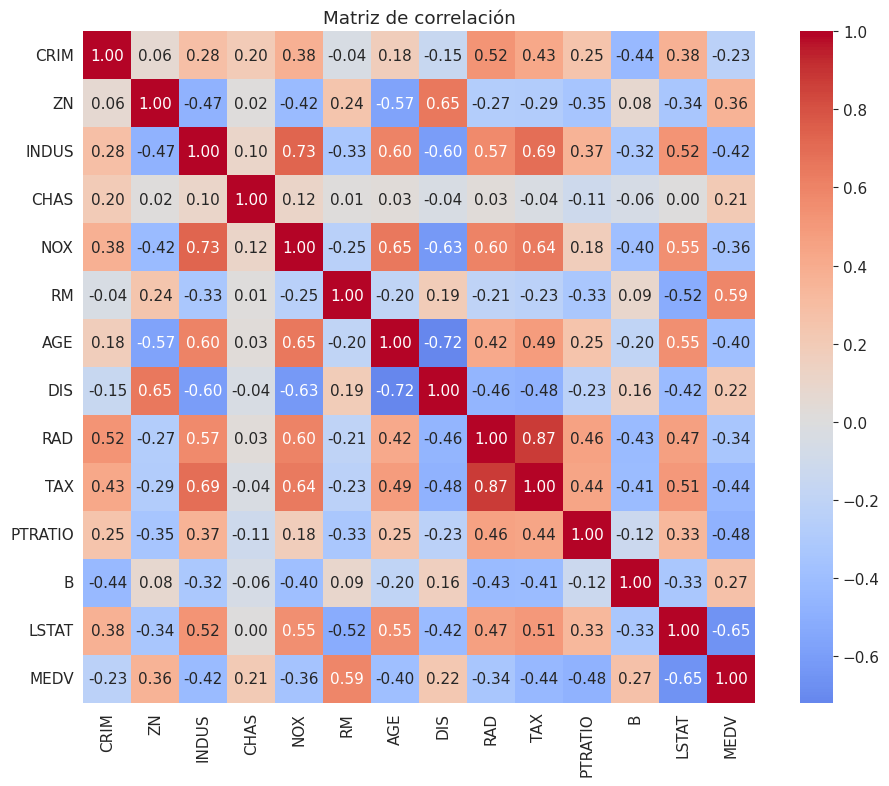

,Correlación con MEDV
RM,0.588080
ZN,0.361685
B,0.270000
DIS,0.223008
CHAS,0.206189
CRIM,-0.228330
RAD,-0.342224
NOX,-0.360711
AGE,-0.396590
INDUS,-0.418512


In [8]:
# Medir relaciones lineales entre variables y ordenar la correlación con MEDV.
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()
display(corr['MEDV'].drop('MEDV').sort_values(ascending=False).to_frame('Correlación con MEDV'))

Las variables con mayor correlación lineal con MEDV son LSTAT (-0.65) y RM (0.59), seguidas por PTRATIO (-0.48). Las más débiles son CHAS, DIS y CRIM. Por eso se eligieron RM y LSTAT para los scatterplots siguientes.

La correlación lineal más alta con MEDV es la de LSTAT (-0.65), lo que indica que ninguna variable por sí sola tiene una relación lineal muy fuerte con el precio.

Además, hay correlaciones altas entre variables predictoras, como RAD–TAX (0.87), INDUS–NOX (0.73) y AGE–DIS (-0.72). Esta multicolinealidad puede volver inestables los coeficientes de una regresión lineal, algo que los métodos de regularización utilizados más adelante (Ridge, Lasso y Elastic Net) ayudan a mitigar.

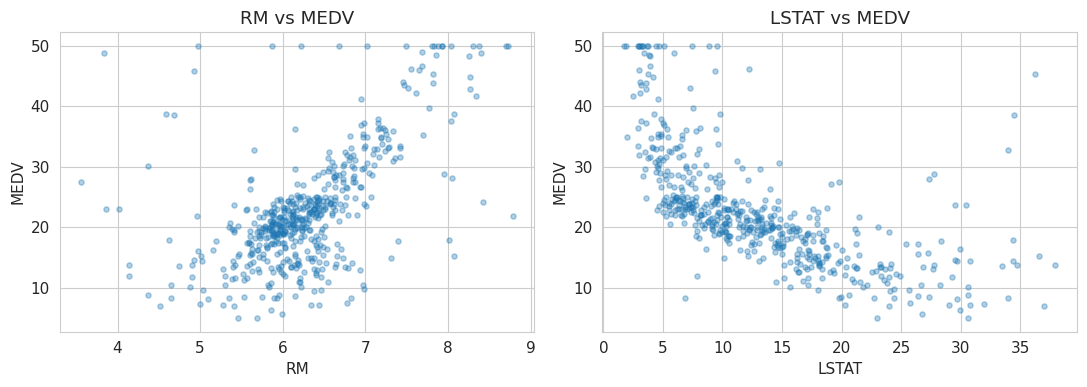

In [9]:
# Graficar las dos variables con mayor relación lineal con MEDV según la matriz de correlación.
variables_clave = ['RM', 'LSTAT']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, variable in zip(axes, variables_clave):
    ax.scatter(df[variable], df['MEDV'], alpha=0.35, s=14)
    ax.set_xlabel(variable)
    ax.set_ylabel('MEDV')
    ax.set_title(f'{variable} vs MEDV')
plt.tight_layout()
plt.show()

Se grafican RM y LSTAT, las dos variables con mayor correlación con MEDV (0.59 y -0.65).

RM tiene una relación positiva y aproximadamente lineal con MEDV: mientras más habitaciones hay por vivienda, mayor es el precio, aunque con dispersión considerable.

LSTAT tiene una relación negativa con MEDV: a mayor porcentaje de población de menor estatus, menor precio. La relación no es del todo lineal: la caída es pronunciada cuando LSTAT pasa de valores bajos a intermedios y se atenúa para valores altos, donde el precio se mantiene bajo. La curvatura sugiere que un modelo lineal no captura del todo esta relación.

En ambos gráficos se observa la acumulación de puntos en MEDV = 50 ya mencionada.

In [10]:
# Dividir antes de imputar y escalar para evitar data leakage.
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X = df_modelo.drop('MEDV', axis=1)
y = df_modelo['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ajustar imputador y scaler solo con train; test se transforma con esos parámetros.
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X.columns, index=X_test.index)
print(f'Train: {len(X_train)} | Test: {len(X_test)} | Faltantes luego del preprocesamiento: {X_train_scaled.isna().sum().sum() + X_test_scaled.isna().sum().sum()}')

Train: 428 | Test: 107 | Faltantes luego del preprocesamiento: 0


---

## Consigna 4: Regresión lineal múltiple

Se comparan `LinearRegression`, gradiente descendente manual, Ridge, Lasso y Elastic Net. Se informan R², RMSE y MAE en train y test; se usa RMSE de test como criterio principal.

In [11]:
# Definir las métricas mínimas para medir ajuste y generalización.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def metricas(nombre, y_train_real, y_train_pred, y_test_real, y_test_pred):
    return {
        'Modelo': nombre,
        'R² Train': r2_score(y_train_real, y_train_pred),
        'R² Test': r2_score(y_test_real, y_test_pred),
        'RMSE Train': mean_squared_error(y_train_real, y_train_pred) ** 0.5,
        'RMSE Test': mean_squared_error(y_test_real, y_test_pred) ** 0.5,
        'MAE Train': mean_absolute_error(y_train_real, y_train_pred),
        'MAE Test': mean_absolute_error(y_test_real, y_test_pred),
    }

In [12]:
# Implementación manual de descenso de gradiente para regresión lineal múltiple.
def gradiente_descendente(X, y, learning_rate=0.01, epochs=1000):
    """
    Ajusta y = X @ w + b minimizando el MSE mediante descenso de gradiente.
    Devuelve los pesos w, el bias b y la lista de MSE por época (losses).
    """
    w = np.zeros(X.shape[1])
    b = 0.0
    losses = []
    for _ in range(epochs):
        pred = X @ w + b
        error = pred - y
        losses.append(np.mean(error ** 2))
        w -= learning_rate * (2 / len(X)) * (X.T @ error)
        b -= learning_rate * (2 / len(X)) * error.sum()
    return w, b, losses

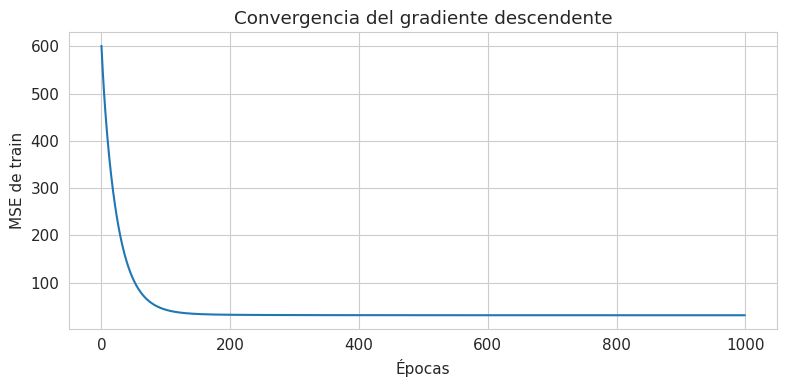

In [13]:
# Entrenar los cinco modelos requeridos y conservar sus predicciones.
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

pred_train, pred_test = {}, {}

lr = LinearRegression().fit(X_train_scaled, y_train)
pred_train['LinearRegression'] = lr.predict(X_train_scaled)
pred_test['LinearRegression'] = lr.predict(X_test_scaled)

# Gradiente descendente manual sobre features estandarizadas.
Xtr, Xte = X_train_scaled.to_numpy(), X_test_scaled.to_numpy()
ytr, yte = y_train.to_numpy(), y_test.to_numpy()
w, b, losses = gradiente_descendente(Xtr, ytr, learning_rate=0.01, epochs=1000)
pred_train['Gradiente Descendente'] = Xtr @ w + b
pred_test['Gradiente Descendente'] = Xte @ w + b

# Graficar la única curva solicitada: error de entrenamiento por época.
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Épocas')
plt.ylabel('MSE de train')
plt.title('Convergencia del gradiente descendente')
plt.tight_layout()
plt.show()

# Entrenar los métodos regularizados con hiperparámetros fijos.
regularizados = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Elastic Net': ElasticNet(alpha=0.1, l1_ratio=0.5),
}
for nombre, modelo in regularizados.items():
    modelo.fit(X_train_scaled, y_train)
    pred_train[nombre] = modelo.predict(X_train_scaled)
    pred_test[nombre] = modelo.predict(X_test_scaled)

In [14]:
# Comparar todos los modelos y evaluar el fitting mediante la brecha de R².
tabla = pd.DataFrame([
    metricas(nombre, y_train, pred_train[nombre], y_test, pred_test[nombre])
    for nombre in pred_train
]).sort_values('RMSE Test').reset_index(drop=True)
display(tabla.round(4))

mejor = tabla.iloc[0]
brecha_r2 = mejor['R² Train'] - mejor['R² Test']
print(f"Mejor modelo por RMSE de test: {mejor['Modelo']} ({mejor['RMSE Test']:.4f} k$)")
print(f"Brecha R² train-test: {brecha_r2:.4f}")
print('Fitting razonable con señales de sobreajuste.' if brecha_r2 >= 0.20 else 'Fitting óptimo sin señales importantes.')

,Modelo,R² Train,R² Test,RMSE Train,RMSE Test,MAE Train,MAE Test
0,Elastic Net,0.6579,0.3744,5.5936,7.2131,3.7886,4.4799
1,Lasso,0.6594,0.3316,5.5815,7.4561,3.8154,4.6227
2,Ridge,0.6634,0.3075,5.5486,7.5892,3.8453,4.6783
3,Gradiente Descendente,0.6633,0.3052,5.5492,7.6016,3.8456,4.6803
4,LinearRegression,0.6634,0.3041,5.5486,7.6080,3.8495,4.6898


Mejor modelo por RMSE de test: Elastic Net (7.2131 k$)
Brecha R² train-test: 0.2835
Fitting razonable con señales de sobreajuste.


### ¿Por qué evaluar en train y en test?
El R² y el RMSE de train miden qué tan bien el modelo ajustó los datos que ya vio, pero no dicen nada sobre su capacidad de generalizar. Evaluar también en test permite detectar sobreajuste: si el error en train es mucho menor que en test, el modelo memorizó parte del ruido de los datos de entrenamiento en vez de aprender un patrón que se sostenga en datos nuevos.

###¿Hubo algún cambio entre LinearRegression y el Gradiente Descendente manual?
Prácticamente ninguno: R² de test 0.3041 (LinearRegression) contra 0.3052 (Gradiente Descendente), y RMSE de test 7.608 contra 7.602. Es el resultado esperado, porque ambos métodos resuelven el mismo problema de optimización (minimizar el MSE de una regresión lineal), que es convexo y tiene un único mínimo: LinearRegression lo calcula de forma cerrada y el Gradiente Descendente llega a él de forma iterativa, pero convergen prácticamente al mismo punto.

###¿Se consiguió un buen fitting?
No completamente. Incluso el mejor modelo (Elastic Net) tiene una brecha de R² train-test de 0.28 (0.66 en train contra 0.37 en test), lo que indica sobreajuste: el modelo explica bastante mejor los datos que ya vio que los nuevos. Además, un R² de test de 0.37 significa que el modelo solo explica alrededor de un tercio de la variación del precio de las viviendas, dejando bastante margen de error. Esto motiva probar los métodos de regularización de la sección siguiente, que buscan reducir esa brecha.

## Consigna 5: Optimización de hiperparámetros

1. Variación de hiperparámetros en Gradiente Descendente (Learning Rate)
Al modificar la tasa de aprendizaje (learning rate o $\alpha$), se altera mucho la convergencia del modelo.
* Si el valor es muy bajo, el modelo da pasos demasiado pequeños y requiere muchísimas épocas para llegar al mínimo, volviéndose muy lento.
* Si el valor es óptimo, converge rápida y suavemente al mínimo.
* Si el valor es demasiado alto, el algoritmo da saltos bruscos, fallando en encontrar el valle y pudiendo divergir (el error crece en lugar de disminuir).

2. Variación de hiperparámetros en Lasso y Ridge (Alpha o $\lambda$)
El hiperparámetro alpha controla qué tan fuerte es la penalización en la función de costo por tener coeficientes grandes.
* Con un alpha muy bajo (ej. 0.01), el castigo es casi nulo y los modelos se comportan igual a la Regresión Lineal clásica.
* Con un alpha moderado, se logra el objetivo de la regularización: armonizar pesos (Ridge) o anular variables irrelevantes (Lasso) para mitigar el sobreajuste.
* Con un alpha excesivamente alto, el castigo puede dominar la función de costo y producir underfitting, como se observa en Lasso (alpha ≥ 10). En Ridge, en el rango probado, esto no llegó a ocurrir.

MSE final con lr=0.1: 30.786853374319808


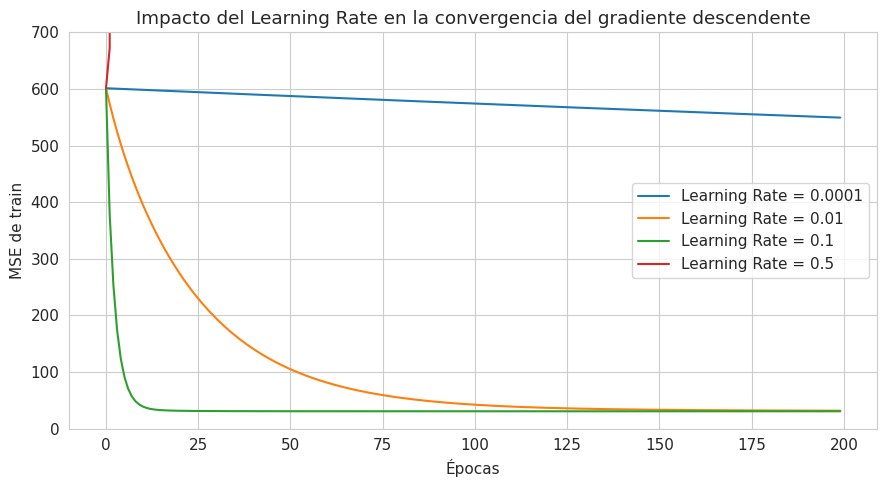

--- Impacto del hiperparámetro Alpha en el rendimiento (Test) ---


,Alpha (Castigo),R² Test Ridge,R² Test Lasso
0,0.01,0.3041,0.3074
1,1.00,0.3075,0.4908
2,10.00,0.3352,-0.0085
3,100.00,0.4532,-0.0085


In [15]:
# 5.1 Variar hiperparámetros de Gradiente Descendente (Learning Rate)

# TEORÍA: El 'Learning Rate' (tasa de aprendizaje o alfa) define el tamaño de los pasos
# que da el algoritmo en la dirección opuesta al gradiente para minimizar la función de costo (MSE).
# - Si es muy grande: el modelo "salta" el mínimo y diverge (el error crece).
# - Si es muy chico: tarda demasiadas épocas en converger (es computacionalmente ineficiente).

tasas_aprendizaje = [0.0001, 0.01, 0.1, 0.5]
plt.figure(figsize=(9, 5))

for lr_val in tasas_aprendizaje:
    # Reutilizamos la misma función de descenso de gradiente, variando solo el learning rate
    _, _, losses_tmp = gradiente_descendente(Xtr, ytr, learning_rate=lr_val, epochs=200) # Usamos _ para recibir w y b, pero no los usamos, necesitamos solo losses.

    # Graficamos la curva de convergencia para esta tasa de aprendizaje específica
    plt.plot(losses_tmp, label=f'Learning Rate = {lr_val}')

    if lr_val == 0.1:
      print('MSE final con lr=0.1:', losses_tmp[-1])

plt.ylim(0, 700)  # acota el eje: con lr=0.5 el error diverge y aplastaría al resto
plt.xlabel('Épocas')
plt.ylabel('MSE de train')
plt.title('Impacto del Learning Rate en la convergencia del gradiente descendente')
plt.legend()
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------
# 5.2 Variar hiperparámetros de Ridge y Lasso (Alpha / Nivel de castigo)
# ---------------------------------------------------------
# TEORÍA: El parámetro 'alpha' (lambda en la fórmula matemática)
# controla la fuerza de la penalización que se le aplica a los coeficientes (betas).
# El objetivo de variar este parámetro es encontrar el punto exacto que reduzca
# la varianza (overfitting) introduciendo solo un poco de sesgo.

alphas_prueba = [0.01, 1.0, 10.0, 100.0]
resultados_reg = []

for alfa in alphas_prueba:
    # Entrenar Ridge (Penalización L2 - Restricción circular)
    # TEORÍA: Ridge encoge los coeficientes correlacionados acercándolos entre sí, pero rara vez los lleva a cero.
    modelo_r = Ridge(alpha=alfa, random_state=42)
    modelo_r.fit(X_train_scaled, y_train)
    pred_train[f'Ridge (alpha={alfa:g})'] = modelo_r.predict(X_train_scaled)
    pred_test[f'Ridge (alpha={alfa:g})'] = modelo_r.predict(X_test_scaled)
    r2_test_r = r2_score(y_test, pred_test[f'Ridge (alpha={alfa:g})'])

    # Entrenar Lasso (Penalización L1 - Restricción en forma de rombo)
    # TEORÍA: Lasso fuerza a que algunos coeficientes se vuelvan exactamente cero, haciendo selección automática de features.
    modelo_l = Lasso(alpha=alfa, random_state=42)
    modelo_l.fit(X_train_scaled, y_train)
    pred_train[f'Lasso (alpha={alfa:g})'] = modelo_l.predict(X_train_scaled)
    pred_test[f'Lasso (alpha={alfa:g})'] = modelo_l.predict(X_test_scaled)
    r2_test_l = r2_score(y_test, pred_test[f'Lasso (alpha={alfa:g})'])

    # Guardamos los resultados para ver cómo evoluciona el R2 en Test al aumentar el castigo
    resultados_reg.append({
        'Alpha (Castigo)': alfa,
        'R² Test Ridge': r2_test_r,
        'R² Test Lasso': r2_test_l
    })

df_alphas = pd.DataFrame(resultados_reg)
print("--- Impacto del hiperparámetro Alpha en el rendimiento (Test) ---")
display(df_alphas.round(4))

0.0001: los pasos son demasiado chicos; tras 200 épocas el MSE apenas bajó (de ~600 a ~550).


0.01: converge, pero más lento; en la época 100 llega a ~40 y todavía no alcanzó el mínimo.


0.1: es el más rápido; ya en la época 10 el MSE está cerca de 40 y en la 199 alcanza ~30.8, el valor de la regresión lineal clásica.


0.5: diverge; el error crece en lugar de disminuir. Esto ocurre porque el paso supera el máximo que permite la curvatura de la función de costo.

Con alpha bajo (0.01), Ridge y Lasso dan un R² de test ≈ 0.30, similar a la regresión lineal clásica.

En Lasso, alpha = 1 mejora el R² de test a 0.49, pero con alpha ≥ 10 cae a ≈ 0: el castigo es tan fuerte que el modelo deja de predecir mejor que la media (underfitting).

En Ridge, en cambio, el R² de test mejora a medida que sube alpha en el rango probado (0.30 con 0.01 y 0.45 con 100).

In [ ]:
# 5.3 Seleccionar hiperparámetros con CV de 5 folds, usando solo el conjunto de entrenamiento.
# El Pipeline ajusta imputación y escalado dentro de cada fold para evitar fuga de información.
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet

cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

def crear_pipeline(modelo):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', modelo),
    ])

alphas = np.logspace(-2, 3, 50)
modelos_y_grillas = {
    'Ridge (CV)': (Ridge(), {'model__alpha': alphas}),
    'Lasso (CV)': (Lasso(max_iter=10000), {'model__alpha': alphas}),
    'Elastic Net (CV)': (
        ElasticNet(max_iter=10000),
        {'model__alpha': alphas, 'model__l1_ratio': [0.1, 0.5, 0.9]},
    ),
}

busquedas_cv = {}
for nombre, (estimador, grilla) in modelos_y_grillas.items():
    busqueda = GridSearchCV(
        estimator=crear_pipeline(estimador),
        param_grid=grilla,
        cv=cv5,
        scoring='r2',
        refit=True,
    )
    # Se usan los datos originales: el Pipeline procesa cada fold por separado.
    busqueda.fit(X_train, y_train)
    busquedas_cv[nombre] = busqueda
    pred_train[nombre] = busqueda.predict(X_train)
    pred_test[nombre] = busqueda.predict(X_test)
    print(nombre, '-> parámetros:', busqueda.best_params_, '| R² CV:', round(busqueda.best_score_, 4))


GridSearchCV compara los hiperparámetros con el R² promedio de cinco folds del conjunto de entrenamiento. En cada fold, el Pipeline ajusta el imputador y el escalador usando solo los datos de entrenamiento de ese fold; el test queda reservado para evaluar después las configuraciones seleccionadas.

In [ ]:
# -------------------------------------------------------------------
# Consigna 6: Comparación y selección del mejor modelo
# -------------------------------------------------------------------

# Se recalcula porque ahora incluye también los modelos con hiperparámetros elegidos por validación cruzada (celda de la Consigna 5.3).
tabla_comparativa = pd.DataFrame([
    metricas(nombre, y_train, pred_train[nombre], y_test, pred_test[nombre])
    for nombre in pred_train
]).sort_values('RMSE Test').reset_index(drop=True)

print("--- Tabla de Posiciones de Modelos ---")
display(tabla_comparativa.round(4))

# Elegimos el menor RMSE entre todas las configuraciones comparadas.
mejor_modelo = tabla_comparativa.iloc[0]
brecha_r2 = mejor_modelo['R² Train'] - mejor_modelo['R² Test']

print("-" * 60)
print(f"MEJOR MODELO: {mejor_modelo['Modelo']}")
print(f"RMSE Test (Error promedio): {mejor_modelo['RMSE Test']:.4f} k$")
print(f"Brecha de R² (Train - Test): {brecha_r2:.4f}")

if brecha_r2 >= 0.20:
    print('Conclusión del Fitting: Fitting razonable, pero aún conserva señales de sobreajuste (alta varianza).')
else:
    print('Conclusión del Fitting: Fitting óptimo y robusto, sin señales importantes de sobreajuste.')

## Consigna 6: Comparación de modelos

### Elección de la métrica

Usamos RMSE en el conjunto de prueba como métrica principal. Está expresada en las mismas unidades que MEDV (miles de dólares) y penaliza más los errores grandes. R² y MAE se muestran como métricas complementarias.

### Selección del modelo

La tabla final incluye los modelos base, las cuatro alphas probadas para Ridge y Lasso, y los modelos ajustados por validación cruzada. Se ordena por RMSE Test y la primera fila identifica el mejor resultado entre las configuraciones comparadas. Ejecutá el notebook completo para regenerar la tabla actualizada.


## 7. Conclusión

El presente Trabajo Práctico permitió abordar de manera integral un problema de regresión utilizando el dataset de precios de viviendas de Boston. El desarrollo siguió un flujo de trabajo riguroso que abarcó desde el entendimiento de los datos hasta la optimización de algoritmos:

* Exploración y Limpieza de Datos: El análisis inicial mediante histogramas y diagramas de caja fue clave para comprender la distribución de las variables y la presencia de valores extremos (outliers). A su vez, la matriz de correlación nos permitió confirmar numéricamente qué características tienen mayor impacto lineal sobre el precio de las viviendas (como el número de habitaciones RM o el estatus socioeconómico LSTAT).
* Preprocesamiento Riguroso: Se tomó la decisión de eliminar las filas sin variable objetivo (MEDV) y de imputar los faltantes restantes usando la mediana. Para prevenir la Fuga de Datos (*Data Leakage*), tanto la imputación como el escalado (StandardScaler) se ajustaron estrictamente después de separar los datos en Train y Test. El escalado fue necesario dada la gran diferencia en los rangos de las variables.
* Diagnóstico del Modelo Base: Al entrenar los modelos de Regresión Lineal clásica y Gradiente Descendente, se logró la convergencia matemática esperada. Sin embargo, la evaluación simultánea en entrenamiento y prueba reveló una brecha en el R² superior a 0.28, indicando que el modelo presentaba señales de sobreajuste (overfitting) o alta varianza, memorizando parte del ruido de los datos.
* Mitigación mediante Regularización: Para resolver este problema, se implementaron modelos penalizados (Ridge, Lasso y Elastic Net). Mediante la optimización de hiperparámetros (Consigna 5), comprobamos empíricamente cómo regular el nivel de castigo a los coeficientes permite sacrificar un mínimo de precisión en entrenamiento a cambio de mejorar notablemente la capacidad de generalización ante datos nuevos.
* Selección Final: La tabla comparativa incluye las cuatro alphas probadas para Ridge y Lasso, y ordena todas las configuraciones por RMSE en Test. El modelo de menor error aparece primero.

## Cierre

La tabla final permite seleccionar el modelo con menor RMSE de test y comparar su generalización mediante la diferencia entre train y test, incluyendo tanto los modelos con hiperparámetros fijos como los ajustados por validación cruzada en la Consigna 5.3.